# Tech Challenge Fase 3 — Pipeline State of Data Brasil

Notebook de entrega do Tech Challenge Fase 3 (POSTECH DTAT). Demonstra o ciclo completo:
ingestão, tratamento, transformação, catalogação, consultas analíticas e geração dos dados
usados nos gráficos.

O notebook **importa os módulos de `src/`** em vez de duplicar lógica. O que é executado aqui
é exatamente o mesmo código que roda nos Glue Jobs — a única diferença é o ambiente detectado
em tempo de execução.

## Ambiente

PySpark 3.5.4 sobre Python 3.10, espelhando o runtime do Glue 5.0. Requer Java 17:

```bash
export JAVA_HOME=/opt/homebrew/opt/openjdk@17
.venv-spark/bin/python -m jupyter notebook
```

Use Python 3.10 ou 3.11; o PySpark 3.5.x não é compatível com Python 3.12 ou superior.

In [1]:
import os
import sys
from pathlib import Path

# Permite importar `src` a partir da raiz do projeto.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
os.environ.setdefault("JAVA_HOME", "/opt/homebrew/opt/openjdk@17")

import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)

from src import config

print("raiz do projeto: diretório do repositório (caminho omitido)")
print(f"respondentes esperados: {config.TOTAL_RESPONDENTES_ESPERADO}")
print(f"conta AWS: identificador omitido · região: {config.REGIAO}")

raiz do projeto: diretório do repositório (caminho omitido)
respondentes esperados: 14005
conta AWS: identificador omitido · região: us-east-1


---
## 1. O problema central: as três edições não são compatíveis

Antes de qualquer transformação, é preciso entender por que unir as edições é o risco principal
deste projeto.

Duas incompatibilidades coexistem. A convenção de nome mudou entre 2023 e 2024, e as **letras
das perguntas deslocam** entre edições porque perguntas foram inseridas e removidas. O mesmo
código representa perguntas diferentes em anos diferentes.

A célula abaixo demonstra o problema com os dados reais.

In [2]:
from src.mapeamento_colunas import ANOS, ARQUIVO_BRUTO, ROTULO_EDICAO, construir_indice

cabecalhos = {
    ano: list(
        pd.read_csv(config.DIRETORIO_BRUTO / ARQUIVO_BRUTO[ano], nrows=0, low_memory=False).columns
    )
    for ano in ANOS
}
indices = {ano: construir_indice(colunas) for ano, colunas in cabecalhos.items()}

print("MESMO CÓDIGO, PERGUNTAS DIFERENTES:\n")
for codigo in ["2.q", "4.e", "3.g"]:
    print(f"código {codigo}")
    for ano in ANOS:
        print(f"    {ROTULO_EDICAO[ano]:10} {indices[ano].get(codigo, '(ausente)')[:74]}")
    print()

MESMO CÓDIGO, PERGUNTAS DIFERENTES:

código 2.q
    2023-2024  ('P2_q ', 'Empresa que trabaha passou por layoff em 2023')
    2024-2025  2.q_empresa_passou_por_layoff_em_2024
    2025-2026  2.q_modelo_de_trabalho_atual

código 4.e
    2023-2024  ('P4_e ', 'Entre as linguagens listadas abaixo, qual é a que você mais uti
    2024-2025  4.e_linguagem_mais_usada
    2025-2026  4.e_cloud_(dia_a_dia)

código 3.g
    2023-2024  ('P3_g ', 'Motivos que levam a empresa a não usar AI Genrativa e LLMs')
    2024-2025  3.g_motivos_para_não_usar_ai_generativa_e_llm
    2025-2026  3.g_empresa_está_conseguindo_ter_bons_resultados_com_llms



Um `union` automático pelos códigos comuns às três edições uniria *layoff* com *modelo de
trabalho*, e *linguagem* com *cloud*. O pipeline rodaria sem erro e o material executivo
apresentaria números errados com total confiança.

Por isso a harmonização é **curada à mão por significado**, com 41 dimensões canônicas.

### Gate obrigatório: validação do mapeamento

Confirma que toda dimensão declarada resolve para uma coluna existente, e exibe os rótulos das
três edições lado a lado para conferência humana.

In [3]:
from src.mapeamento_colunas import MAPEAMENTO, resolver_colunas
from src.validar_mapeamento import extrair_rotulo

resolvidos = {ano: resolver_colunas(cabecalhos[ano], ano) for ano in ANOS}

# As dimensões cujo código difere entre edições são as de maior risco.
risco = ["layoff", "modelo_trabalho_atual", "linguagem_preferida", "cloud_preferida", "usa_chatgpt_copilot"]

linhas = []
for dimensao in risco:
    registro = {"dimensao": dimensao}
    for ano in ANOS:
        coluna = resolvidos[ano][dimensao]
        registro[ROTULO_EDICAO[ano]] = (
            f"{MAPEAMENTO[dimensao][ano]} · {extrair_rotulo(coluna)[:32]}" if coluna else "ausente"
        )
    linhas.append(registro)

print(f"dimensões canônicas mapeadas: {len(MAPEAMENTO)}\n")
display(pd.DataFrame(linhas))

dimensões canônicas mapeadas: 41



,dimensao,2023-2024,2024-2025,2025-2026
0,layoff,P2_q · Empresa que trabaha passou por l,2.q · empresa_passou_por_layoff_em_202,2.p · empresa_passou_por_layoff_em_202
1,modelo_trabalho_atual,P2_r · Atualmente qual a sua forma de t,2.r · modelo_de_trabalho_atual,2.q · modelo_de_trabalho_atual
2,linguagem_preferida,P4_f · Entre as linguagens listadas aba,4.f · linguagem_preferida,4.c · linguagem_preferida
3,cloud_preferida,P4_i · Cloud preferida,4.i · cloud_preferida,4.f · cloud_preferida
4,usa_chatgpt_copilot,P4_m · Utiliza ChatGPT ou LLMs no traba,4.m · usa_chatgpt_ou_copilot_no_trabal,4.j · usa_chatgpt_ou_copilot_no_trabal


---
## 2. Ingestão — camada Bronze

A Bronze é cópia fiel da origem: nenhuma transformação de conteúdo, nomes de coluna ou tipos.
A validação de contagem falha o pipeline se o arquivo divergir do documentado, porque uma
leitura mal configurada divide ou funde registros sem nenhum erro visível.

In [4]:
from src.contexto_execucao import ContextoExecucao
from src.ingestao import ler_todas_edicoes

contexto = ContextoExecucao("notebook-sod-fase3")
contexto.registrar_ambiente()

brutos = ler_todas_edicoes(contexto)
print(f"\ntotal ingerido: {sum(df.count() for df in brutos.values())} respondentes")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/13 21:52:24 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


[00:52:25][local] ambiente = local


[00:52:25][local] versao_spark = 3.5.4


[00:52:25][local] versao_python = 3.10.19


...

[00:52:27][local] lendo 2024-2025: ./data/raw/state_of_data_2024.csv


[00:52:27][local]   2024-2025: 5217 linhas x 403 colunas


[00:52:27][local] lendo 2025-2026: ./data/raw/state_of_data_2025.csv


[00:52:28][local]   2025-2026: 3495 linhas x 388 colunas



total ingerido: 14005 respondentes


---
## 3. Transformação — camada Silver

Aplica, em ordem: sanitização dos nomes de coluna para compatibilidade com o Athena,
harmonização semântica das três edições, e normalização dos valores categóricos.

**Nenhum `dropna()` é executado.** Os nulos são estruturais: o questionário é condicional e a
seção de gestão só é respondida por gestores. Remover essas linhas descartaria respondentes
válidos e distorceria todo denominador subsequente.

In [5]:
from src.transformacoes import bronze_para_silver, multiescolha

silver = bronze_para_silver.harmonizar(contexto, brutos).cache()
contexto.escrever_parquet(
    silver, config.CAMADA_SILVER, config.TABELA_SILVER, particoes=["edicao"]
)

print(f"\nSilver: {silver.count()} registros × {len(silver.columns)} colunas")

[00:52:28][local] preparando 2023-2024


[00:52:28][local] preparando 2024-2025


[00:52:28][local] preparando 2025-2026


[00:52:28][local] normalizando valores categóricos


[00:52:29][local] nomes de coluna válidos para Athena: 47 colunas


...

[00:52:30][local] faixas salariais válidas: 13 distintas


[00:52:32][local] dimensões consistentes verificadas: sem divergência entre edições


26/09/13 21:52:32 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


[00:52:35][local] escrito: ./data/lake/silver/respondentes (14005 registros)



Silver: 14005 registros × 47 colunas


### Perguntas de múltipla escolha

Não podem ser lidas da coluna raiz: o separador é vírgula, mas os próprios textos das respostas
contêm vírgulas. Uma opção real do questionário é
*"Utilizo soluções pagas de AI Generativa (como por exemplo ChatGPT plus, Anthropic Claude,
Google Gemini etc)..."* — dividir por vírgula fragmentaria a resposta.

A solução usa as colunas booleanas explodidas da origem, transpostas para formato longo.

In [6]:
marcacoes, respondeu = multiescolha.executar(contexto, brutos)

print("\nmarcações por dimensão e edição:")
marcacoes.groupBy("dimensao").pivot("edicao").count().orderBy("dimensao").show(20, False)

[00:52:35][local] extraindo multi-escolha de 2023-2024


[00:52:36][local] extraindo multi-escolha de 2024-2025


[00:52:38][local] extraindo multi-escolha de 2025-2026


26/09/13 21:52:41 WARN DAGScheduler: Broadcasting large task binary with size 1194.1 KiB


[00:52:44][local] escrito: ./data/lake/silver/respostas_multiescolha (169155 registros)


[00:52:48][local] escrito: ./data/lake/silver/respondeu_multiescolha (154055 registros)



marcações por dimensão e edição:


+---------------------+-----+-----+----+
|dimensao             |2023 |2024 |2025|
+---------------------+-----+-----+----+
|aspectos_prejudicados|4406 |4611 |2928|
|banco_dados          |10282|10328|7128|
|bi_dia_a_dia         |6979 |6402 |3723|
|cloud_dia_a_dia      |4810 |4599 |2922|
|criterios_escolha    |13235|13814|9102|
|desafios_gestor      |2395 |2884 |1599|
|linguagem_preferida  |NULL |NULL |4202|
|linguagem_usada      |8109 |7567 |NULL|
|motivos_nao_usar_ia  |1687 |2022 |1218|
|tipo_uso_ia_area     |5534 |6428 |4161|
|tipo_uso_ia_empresa  |1435 |2094 |1389|
|usa_chatgpt_copilot  |4090 |4298 |2774|
+---------------------+-----+-----+----+



---
## 4. Conferência cruzada

As validações internas do pipeline verificam a **integridade** do processamento. Nenhuma delas
verifica se o mapeamento apontou para a coluna **certa**.

Esta etapa recalcula as distribuições diretamente dos CSVs com pandas, por caminho de código
independente do Spark, e compara com a Silver. Divergência aqui significa mapeamento errado.

In [7]:
from src.conferencia_cruzada import carregar_silver_local, conferir

divergencias = conferir(carregar_silver_local(), verboso=True)
assert not divergencias, f"{len(divergencias)} divergências: {divergencias}"

CONFERÊNCIA CRUZADA — Silver (Spark) versus cálculo direto (pandas)

[genero]
    2023-2024  OK   5293 respostas, 4 valores distintos
    2024-2025  OK   5217 respostas, 4 valores distintos


    2025-2026  OK   3495 respostas, 4 valores distintos

[regiao_onde_mora]
    2023-2024  OK   5169 respostas, 5 valores distintos
    2024-2025  OK   5075 respostas, 5 valores distintos


    2025-2026  OK   3370 respostas, 5 valores distintos

[nivel_senioridade]
    2023-2024  OK   3857 respostas, 3 valores distintos
    2024-2025  OK   3818 respostas, 3 valores distintos
    2025-2026  OK   2501 respostas, 4 valores distintos

[faixa_salarial]


    2023-2024  OK   4753 respostas, 13 valores distintos
    2024-2025  OK   4863 respostas, 13 valores distintos
    2025-2026  OK   3228 respostas, 13 valores distintos

[modelo_trabalho_atual]
    2023-2024  OK   4753 respostas, 4 valores distintos


    2024-2025  OK   4863 respostas, 4 valores distintos
    2025-2026  OK   3228 respostas, 4 valores distintos

[layoff]
    2023-2024  OK   4753 respostas, 3 valores distintos


    2024-2025  OK   4863 respostas, 3 valores distintos
    2025-2026  OK   3228 respostas, 3 valores distintos

[linguagem_preferida]
    2023-2024  OK   3750 respostas, 16 valores distintos
    2024-2025  OK   3424 respostas, 33 valores distintos


    2025-2026  OK   2096 respostas, 137 valores distintos

[cloud_preferida]
    2023-2024  OK   3771 respostas, 44 valores distintos
    2024-2025  OK   3589 respostas, 13 valores distintos
    2025-2026  OK   2096 respostas, 11 valores distintos

[cloud_dia_a_dia]


    2023-2024  OK   3613 respostas, 175 valores distintos
    2024-2025  OK   3589 respostas, 221 valores distintos
    2025-2026  OK   2096 respostas, 177 valores distintos

[usa_chatgpt_copilot]
    2023-2024  OK   3772 respostas, 22 valores distintos


    2024-2025  OK   3619 respostas, 24 valores distintos
    2025-2026  OK   2106 respostas, 20 valores distintos

[ia_e_prioridade]
    2023-2024  OK   896 respostas, 5 valores distintos
    2024-2025  OK   1045 respostas, 5 valores distintos


    2025-2026  OK   652 respostas, 5 valores distintos

[motivos_nao_usar_ia]
    2023-2024  OK   822 respostas, 269 valores distintos
    2024-2025  OK   974 respostas, 264 valores distintos
    2025-2026  OK   587 respostas, 201 valores distintos

Nenhuma divergência. O mapeamento semântico está correto para as
dimensões conferidas, incluindo todas as afetadas por deslocamento.


---
## 5. Agregação — camada Gold

Sete tabelas respondem às perguntas de negócio e `salario_medio` é uma tabela auxiliar. Todas seguem o mesmo contrato:

```
dimensões de corte | quantidade | percentual | respondentes_validos | taxa_resposta | fragil
```

`respondentes_validos` é o denominador efetivo, e `taxa_resposta` mostra quanto da base sustenta
o número. É o que impede o erro mais provável do projeto: apresentar um percentual calculado
sobre a base errada.

In [8]:
from src.transformacoes import silver_para_gold

tabelas = silver_para_gold.construir_tabelas(contexto, silver, marcacoes, respondeu)

for nome, df in tabelas.items():
    contexto.escrever_parquet(df, config.CAMADA_GOLD, nome)

[00:53:20][local] gold/perfil_mercado: Como está estruturado o mercado brasileiro de Dados?


[00:53:20][local] gold/remuneracao: Quais perfis profissionais são mais valorizados pelo mercado?


[00:53:20][local] gold/diversidade: Qual é o cenário de diversidade de gênero nas carreiras de dados?


[00:53:20][local] gold/tecnologias: Quais tecnologias apresentam maior adoção entre os profissionais?


[00:53:20][local] gold/adocao_ia: Qual é o índice de adoção de Inteligência Artificial e seu impacto?


...

[00:53:32][local] escrito: ./data/lake/gold/diversidade (433 registros)


[00:53:35][local] escrito: ./data/lake/gold/tecnologias (217 registros)


[00:53:39][local] escrito: ./data/lake/gold/adocao_ia (110 registros)


[00:53:43][local] escrito: ./data/lake/gold/recortes_comparativos (459 registros)


[00:53:47][local] escrito: ./data/lake/gold/oportunidades_desafios (1191 registros)


### 5.1 Código-fonte auditável das transformações

As células anteriores executam diretamente as funções canônicas de `src/`; os Glue Jobs usam as mesmas funções. Para tornar a implementação visível ao avaliador sem manter uma segunda cópia, a célula abaixo projeta automaticamente o código-fonte efetivamente importado.

Na execução local, a etapa Bronze lê e valida `data/raw`. Na AWS, `infra/ingerir_bronze.py` realiza o upload fiel para o S3, e o Glue Job lê o prefixo Bronze. Nenhum caminho absoluto do ambiente local é publicado.

In [9]:
import inspect

funcoes_auditadas = [
    bronze_para_silver.preparar_edicao,
    bronze_para_silver.harmonizar,
    multiescolha.extrair_multiescolha,
    silver_para_gold.agregar_multiescolha,
    silver_para_gold.construir_tabelas,
]

for funcao in funcoes_auditadas:
    print(f"\n# {funcao.__module__}.{funcao.__name__}")
    print(inspect.getsource(funcao))


# src.transformacoes.bronze_para_silver.preparar_edicao
def preparar_edicao(df_bruto: DataFrame, ano: int) -> DataFrame:
    """Extrai e renomeia as dimensões canônicas de uma edição.

    Dimensões ausentes na edição são materializadas como nulo tipado, de modo
    que o `unionByName` posterior encontre schema idêntico nas três edições.

    Args:
        df_bruto: DataFrame bruto da edição, com nomes de coluna da origem.
        ano: ano de início da edição (2023, 2024 ou 2025).

    Returns:
        DataFrame com as dimensões canônicas, `token`, `edicao` e `ingerido_em`.

    Raises:
        ErroDeHarmonizacao: se alguma dimensão declarada como presente no
            mapeamento não resolver para uma coluna existente.
    """
    resolvido = resolver_colunas(df_bruto.columns, ano)

    nao_resolvidas = [
        dimensao
        for dimensao, coluna in resolvido.items()
        if coluna is None and MAPEAMENTO[dimensao][ano] is not None
    ]
    if nao_resolvidas:
        raise Er

### Por que o denominador importa

A célula abaixo mostra o efeito prático. A pergunta sobre prioridade de IA é respondida apenas
por gestores: calcular o percentual sobre a base total erraria por um fator de cinco.

In [10]:
ia = tabelas["adocao_ia"].toPandas()
prioridade = ia[(ia.dimensao == "ia_e_prioridade") & (ia.edicao == 2025)].copy()

prioridade["pct_correto"] = prioridade.percentual
prioridade["pct_se_base_total"] = (prioridade.quantidade / 3495 * 100).round(2)
prioridade["categoria_curta"] = prioridade.categoria.str[:46]

print(f"base correta (gestores): {int(prioridade.respondentes_validos.iloc[0])}")
print(f"base total da edição   : 3495")
print(f"taxa de resposta       : {prioridade.taxa_resposta.iloc[0]}%\n")
display(prioridade[["categoria_curta", "quantidade", "pct_correto", "pct_se_base_total"]])

base correta (gestores): 652
base total da edição   : 3495
taxa de resposta       : 18.66%



,categoria_curta,quantidade,pct_correto,pct_se_base_total
10,"Sim, está entre nossas principais prioridades",240,36.81,6.87
11,Mais ou menos... É uma das várias iniciativas,169,25.92,4.84
12,"Sim, é nossa principal prioridade como empresa",155,23.77,4.43
13,Não é uma iniciativa que estamos focando e não,74,11.35,2.12
14,Não sei opinar sobre esse assunto.,14,2.15,0.40


---
## 6. Análises — as sete perguntas de negócio

As mesmas agregações são consultáveis via SQL no Athena (`athena/00_perguntas_de_negocio.sql`).
Aqui elas são exibidas direto da Gold.

In [11]:
gold = {nome: df.toPandas() for nome, df in tabelas.items()}

print("1. Como está estruturado o mercado brasileiro de Dados?\n")
pm = gold["perfil_mercado"]
display(
    pm[(pm.metrica == "cargo") & (pm.edicao == 2025)]
    .nlargest(8, "percentual")[["categoria", "quantidade", "percentual", "respondentes_validos"]]
)

print("\nSetores empregadores:\n")
display(pm[(pm.metrica == "setor") & (pm.edicao == 2025)].nlargest(5, "percentual")[["categoria", "percentual"]])

1. Como está estruturado o mercado brasileiro de Dados?



,categoria,quantidade,percentual,respondentes_validos
32,Analista de Dados/Data Analyst,599,23.95,2501
33,Cientista de Dados/Data Scientist,424,16.95,2501
34,Engenheiro de Dados/Data Engineer/Data Architect,402,16.07,2501
35,Analista de BI/BI Analyst,215,8.60,2501
36,Outra Opção,206,8.24,2501
37,Analista de Negócios/Business Analyst,141,5.64,2501
38,Analytics Engineer,135,5.40,2501
39,Engenheiro de Machine Learning/ML Engineer/AI Engineer,106,4.24,2501



Setores empregadores:



,categoria,percentual
99,Finanças ou Bancos,18.53
100,Tecnologia/Fábrica de Software,17.44
101,Área de Consultoria,8.83
102,Outra Opção,7.53
103,Indústria,7.37


In [12]:
print("2. Quais perfis profissionais são mais valorizados pelo mercado?\n")
sm = gold["salario_medio"]
display(
    sm[(sm.recorte == "senioridade") & (~sm.fragil)]
    .sort_values(["edicao", "salario_medio"], ascending=[False, False])[
        ["edicao", "categoria", "salario_medio", "salario_mediano", "respondentes_validos"]
    ]
)

2. Quais perfis profissionais são mais valorizados pelo mercado?



,edicao,categoria,salario_medio,salario_mediano,respondentes_validos
134,2025,Especialista/Staff+,20372.96,18000.5,349
135,2025,Sênior,14621.70,14000.5,858
136,2025,Pleno,8314.29,7000.5,776
137,2025,Júnior,4152.99,3500.5,518
82,2024,Sênior,14702.97,14000.5,1573
83,2024,Pleno,8047.70,7000.5,1377
84,2024,Júnior,4163.50,3500.5,868
30,2023,Sênior,13760.89,10000.5,1419
31,2023,Pleno,7546.83,7000.5,1392
32,2023,Júnior,3909.67,3500.5,1046


In [13]:
print("3. Qual é o cenário de diversidade de gênero nas carreiras de dados?\n")
dv = gold["diversidade"]

print("Participação feminina no total, por edição:")
display(
    dv[(dv.metrica == "genero_geral") & (dv.categoria == "Feminino")]
    .sort_values("edicao")[["edicao", "percentual", "respondentes_validos"]]
)

print("\nPor senioridade, edição 2025-2026 — o afunilamento:")
display(
    dv[
        (dv.metrica == "genero_por_senioridade")
        & (dv.categoria == "Feminino")
        & (dv.edicao == 2025)
        & (~dv.fragil)
    ][["nivel_senioridade", "quantidade", "percentual", "respondentes_validos"]]
)

3. Qual é o cenário de diversidade de gênero nas carreiras de dados?

Participação feminina no total, por edição:


,edicao,percentual,respondentes_validos
1,2023,24.43,5293
5,2024,23.50,5217
9,2025,21.97,3495



Por senioridade, edição 2025-2026 — o afunilamento:


,nivel_senioridade,quantidade,percentual,respondentes_validos
66,Especialista/Staff+,70,20.06,349
70,Júnior,146,28.19,518
74,Pleno,174,22.42,776
78,Sênior,178,20.75,858


In [14]:
print("4. Quais tecnologias apresentam maior adoção entre os profissionais?")
print("   Múltipla escolha: a soma excede 100%.\n")
tc = gold["tecnologias"]

print("Cloud no dia a dia, evolução nas três edições:")
display(
    tc[tc.dimensao == "cloud_dia_a_dia"]
    .pivot_table(index="opcao", columns="edicao", values="percentual")
    .sort_values(2025, ascending=False)
)

print("\nBancos de dados, edição 2025-2026:")
display(
    tc[(tc.dimensao == "banco_dados") & (tc.edicao == 2025)]
    .nlargest(8, "percentual")[["opcao", "percentual", "quantidade"]]
)

4. Quais tecnologias apresentam maior adoção entre os profissionais?
   Múltipla escolha: a soma excede 100%.

Cloud no dia a dia, evolução nas três edições:


edicao,2023,2024,2025
opcao,,,
Amazon Web Services (AWS),30.61,44.13,48.28
Azure (Microsoft),42.32,30.87,34.83
Google Cloud (GCP),31.58,29.26,30.87
Servidores On Premise/Não utilizamos Cloud,16.11,12.90,14.31
Cloud Própria,6.95,5.32,5.44
Oracle Cloud,4.26,3.98,4.48
IBM,1.30,1.67,1.19



Bancos de dados, edição 2025-2026:


,opcao,percentual,quantidade
179,PostgreSQL,36.78,771
176,SQL SERVER,33.49,702
190,Databricks,32.87,689
168,S3,28.82,604
175,MySQL,28.53,598
188,Google BigQuery,27.00,566
174,Oracle,19.56,410
189,Amazon Athena,15.22,319


In [15]:
print("5. Qual é o índice de adoção de Inteligência Artificial e seu impacto?\n")
print("Uso de IA generativa no trabalho, evolução nas três edições:")
display(
    ia[ia.dimensao == "usa_chatgpt_copilot"]
    .assign(categoria=lambda d: d.categoria.str[:56])
    .pivot_table(index="categoria", columns="edicao", values="percentual")
)

5. Qual é o índice de adoção de Inteligência Artificial e seu impacto?

Uso de IA generativa no trabalho, evolução nas três edições:


edicao,2023,2024,2025
categoria,,,
A empresa que trabalho paga pelas soluções de AI Generat,6.36,19.26,42.36
Não uso soluções de AI Generativa com foco em produtivid,19.72,6.55,2.09
Uso e pago pelas soluções de AI Generativa com foco em p,6.92,15.53,26.92
Uso soluções do tipo Copilot,11.77,23.71,29.82
Uso soluções gratuitas de AI Generativa com foco em prod,63.65,53.72,30.53


In [16]:
print("6. Existem diferenças relevantes entre regiões, senioridades ou modelos de trabalho?\n")
rc = gold["recortes_comparativos"]

print("Modelo de trabalho: atual contra ideal, edição 2025-2026:")
modelo = rc[
    rc.metrica.isin(["modelo_trabalho_geral", "modelo_trabalho_ideal"]) & (rc.edicao == 2025)
]
comparativo = modelo.pivot_table(index="categoria", columns="metrica", values="percentual")
comparativo["diferenca_pp"] = (
    comparativo["modelo_trabalho_ideal"] - comparativo["modelo_trabalho_geral"]
).round(2)
comparativo.index = [nome[:44] for nome in comparativo.index]
display(comparativo.sort_values("diferenca_pp"))

print("\nSalário médio por região, edição 2025-2026:")
display(
    sm[(sm.recorte == "regiao") & (sm.edicao == 2025) & (~sm.fragil)]
    .sort_values("salario_medio", ascending=False)[
        ["categoria", "salario_medio", "respondentes_validos"]
    ]
)

6. Existem diferenças relevantes entre regiões, senioridades ou modelos de trabalho?

Modelo de trabalho: atual contra ideal, edição 2025-2026:


metrica,modelo_trabalho_geral,modelo_trabalho_ideal,diferenca_pp
Modelo 100% presencial,20.76,1.86,-18.90
Modelo híbrido com dias fixos de trabalho pr,19.98,13.04,-6.94
Modelo 100% remoto,39.71,42.13,2.42
Modelo híbrido flexível (o funcionário tem l,19.55,42.97,23.42



Salário médio por região, edição 2025-2026:


,categoria,salario_medio,respondentes_validos
129,Sudeste,13696.04,2025
130,Centro-oeste,13038.94,221
131,Norte,12958.76,36
132,Sul,12375.97,510
133,Nordeste,10436.66,329


In [17]:
print("7. Quais oportunidades e desafios para empresas que investem em Dados e IA?\n")
od = gold["oportunidades_desafios"]

print("Critérios na escolha de um emprego, edição 2025-2026:")
display(
    od[(od.dimensao == "criterios_escolha") & (od.edicao == 2025) & (~od.fragil)]
    .nlargest(8, "percentual")
    .assign(categoria=lambda d: d.categoria.str[:50])[["categoria", "percentual", "quantidade"]]
)

print("\nMaiores desafios declarados por gestores:")
display(
    od[(od.dimensao == "desafios_gestor") & (od.edicao == 2025) & (~od.fragil)]
    .nlargest(6, "percentual")
    .assign(categoria=lambda d: d.categoria.str[:50])[
        ["categoria", "percentual", "respondentes_validos", "taxa_resposta"]
    ]
)

7. Quais oportunidades e desafios para empresas que investem em Dados e IA?

Critérios na escolha de um emprego, edição 2025-2026:


,categoria,percentual,quantidade
1175,Remuneração/Salário,83.21,2686
1181,Flexibilidade de trabalho remoto,56.60,1827
1177,Plano de carreira e oportunidades de crescimento,32.34,1044
1172,Benefícios,24.50,791
1173,Oportunidade de aprendizado e trabalhar com referê,23.67,764
1174,Ambiente e clima de trabalho,21.41,691
1180,Propósito do trabalho e da empresa,15.71,507
1178,Maturidade da empresa em termos de tecnologia e da,10.84,350



Maiores desafios declarados por gestores:


,categoria,percentual,respondentes_validos,taxa_resposta
1159,Dividir o tempo entre entregas técnicas e gestão,36.35,652,18.66
1162,Gerenciar a expectativa das áreas,33.28,652,18.66
1165,Gestão de projetos envolvendo áreas multidisciplin,29.14,652,18.66
1163,Gerar valor para as áreas de negócios,23.47,652,18.66
1170,Organizar as informações com qualidade e confiabil,21.63,652,18.66
1161,Garantir a manutenção dos projetos e modelos em pr,20.40,652,18.66


---
## 7. Geração dos gráficos e do material executivo

Os gráficos são gerados exclusivamente a partir da camada Gold, nunca dos CSVs brutos. Cada
figura declara a base (`n`) e as ressalvas metodológicas aplicáveis.

In [18]:
contexto.encerrar()  # libera a SparkSession antes das etapas em pandas

from src.gerador_graficos import gerar_todos

gerados = gerar_todos()

GERAÇÃO DE GRÁFICOS — a partir da camada Gold
  1. Estrutura do mercado        01_perfil_mercado.png                67.0 KB


  2. Perfis mais valorizados     02_remuneracao_senioridade.png       54.4 KB
  3. Diversidade de gênero       03_diversidade_senioridade.png       53.0 KB


  4. Adoção de tecnologias       04_tecnologias_cloud.png             47.8 KB
  5. Adoção de IA                05_adocao_ia.png                     54.2 KB


  6. Recortes regionais          06_recortes_regionais.png            64.0 KB
  6. Modelo de trabalho          07_modelo_trabalho.png               37.2 KB


  7. Critérios de escolha        08_criterios_escolha.png             58.9 KB
  7. Barreiras à IA              09_barreiras_ia.png                  69.5 KB

9 gráficos em output/img



1. Estrutura do mercado


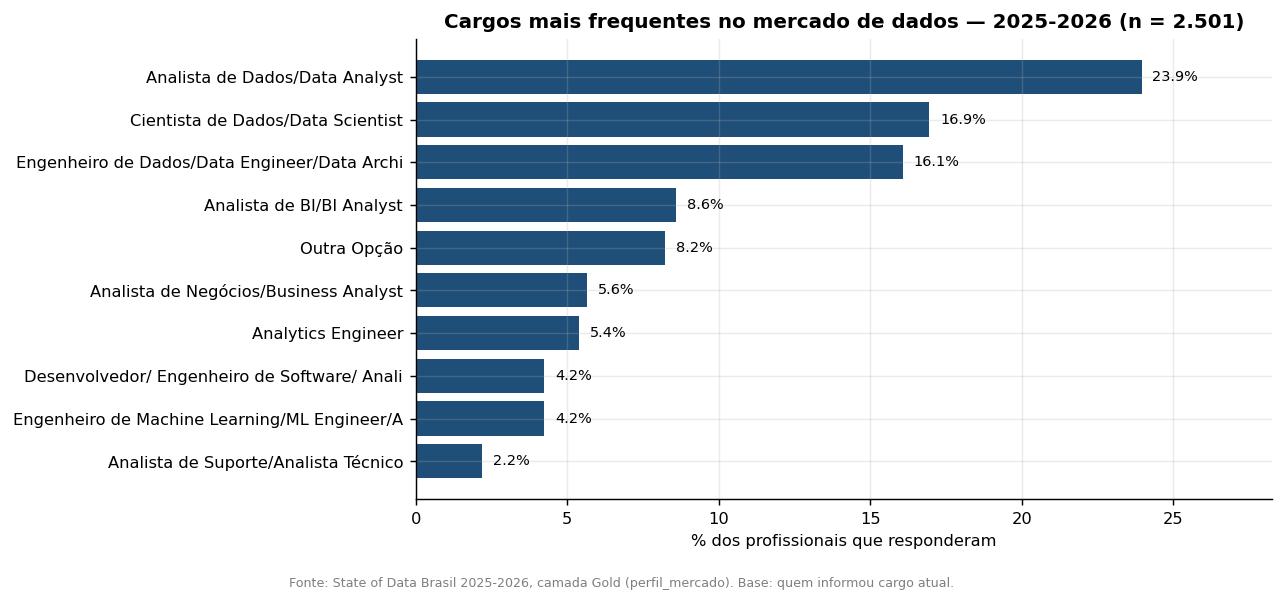


2. Perfis mais valorizados


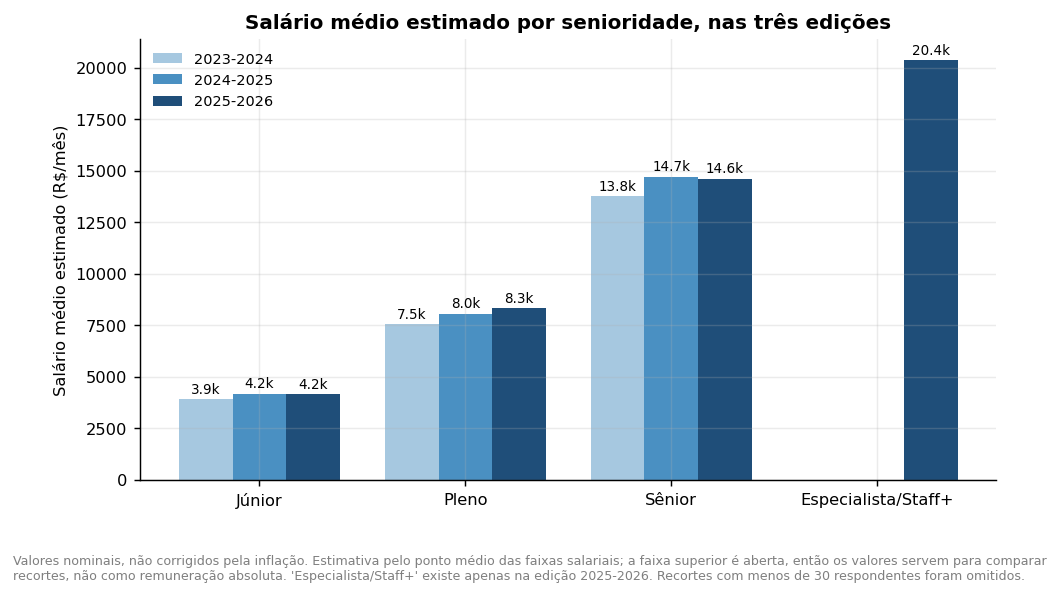


3. Diversidade de gênero


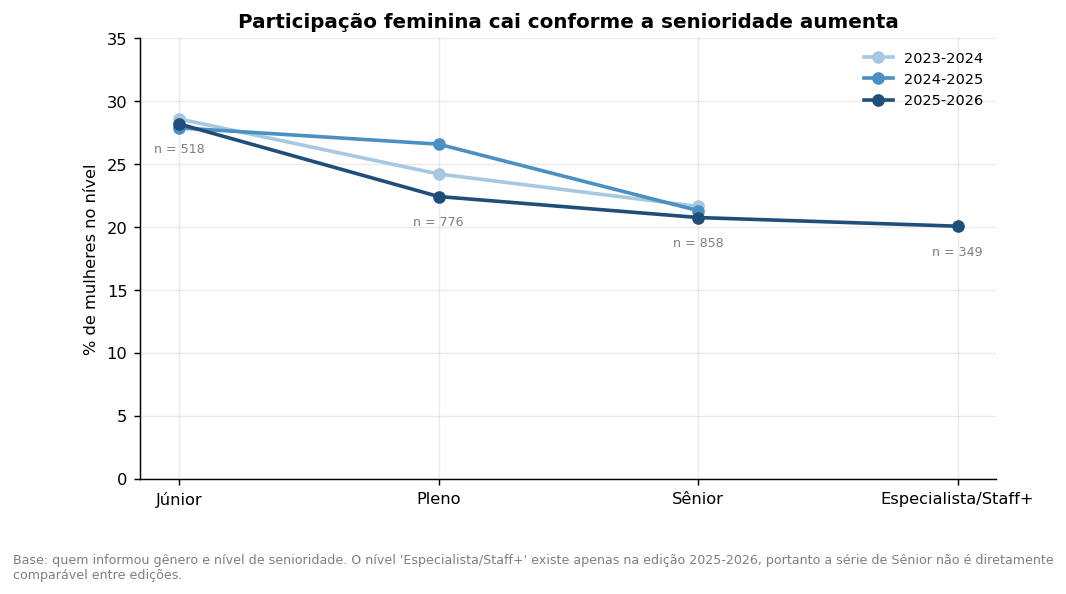


4. Adoção de tecnologias


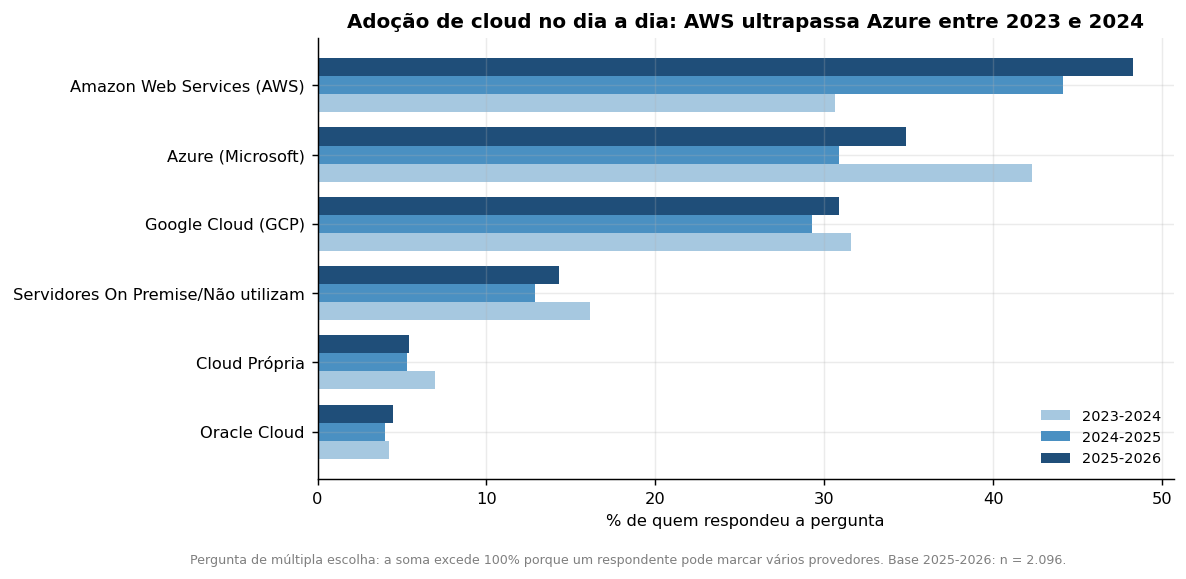


5. Adoção de IA


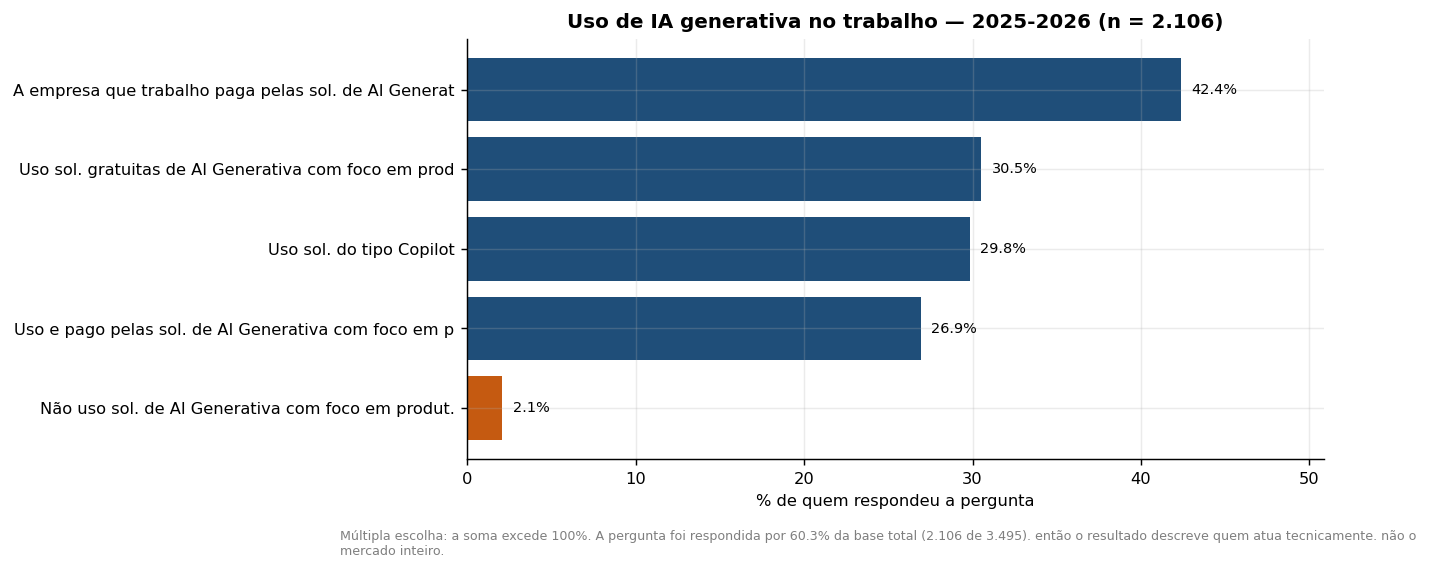


6. Recortes regionais


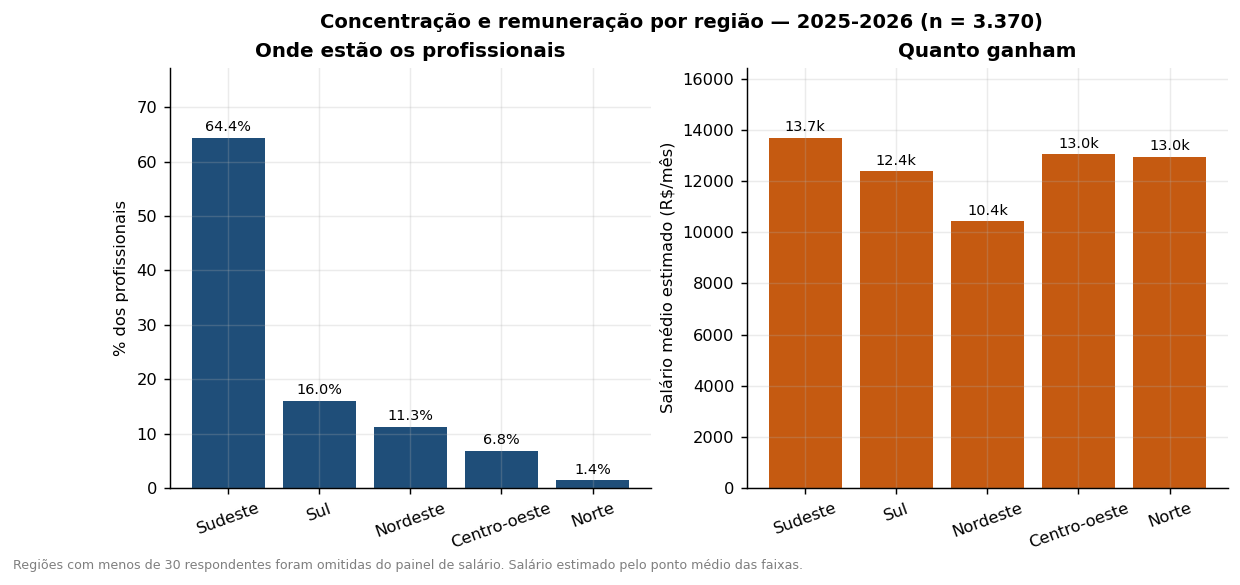


6. Modelo de trabalho


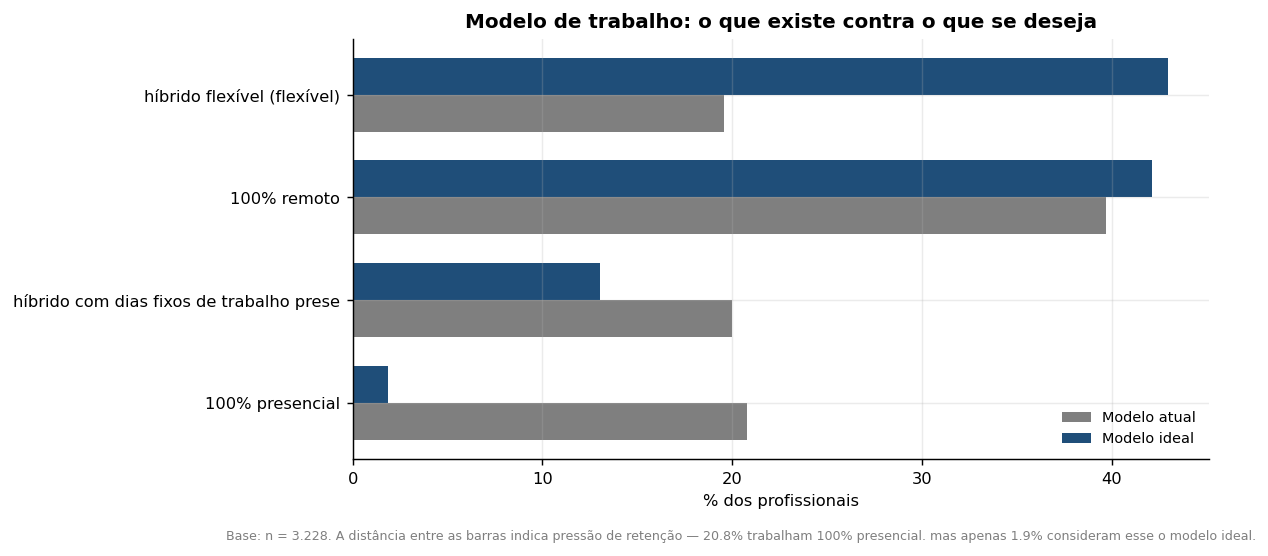


7. Critérios de escolha


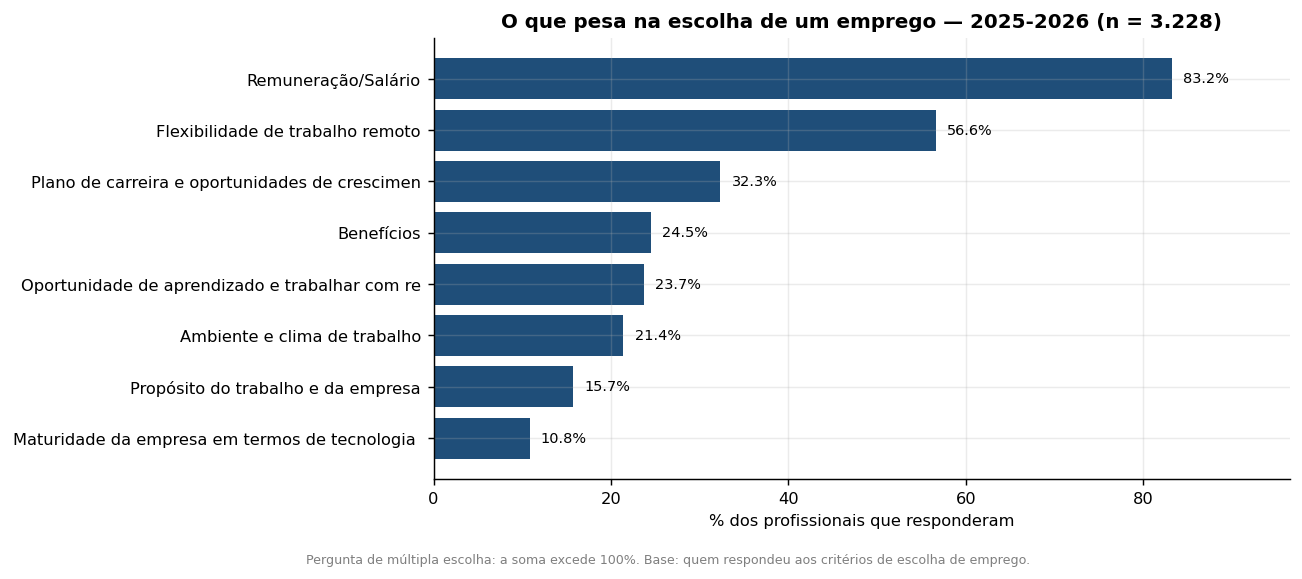


7. Barreiras à IA


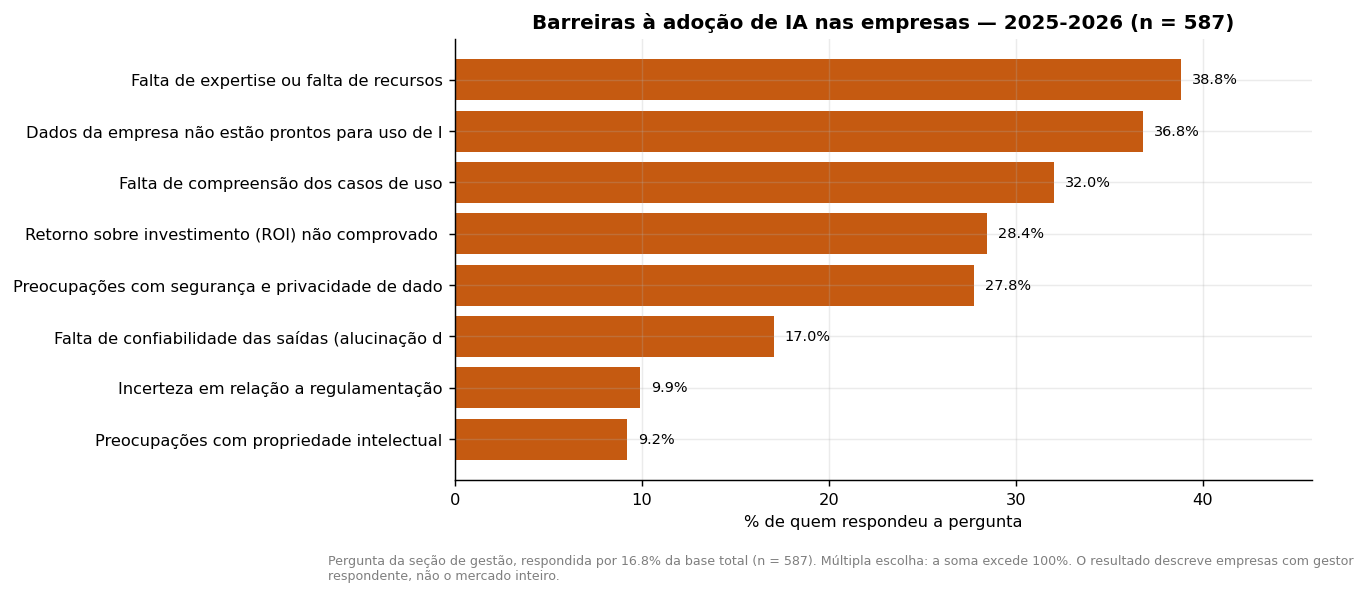

In [19]:
from IPython.display import Image, display as mostrar

for rotulo, caminho in gerados.items():
    print(f"\n{rotulo}")
    mostrar(Image(filename=str(caminho), width=900))

---
## 8. Execução na AWS

O mesmo código executado acima roda nos Glue Jobs sem alteração. As células abaixo estão
comentadas porque criam recursos e geram custo — descomente para executar.

```python
from infra import provisionar, ingerir_bronze, executar_jobs, catalogar, executar_consultas

provisionar.provisionar()      # bucket privado, IAM role escopada, Glue Database
ingerir_bronze.ingerir()       # sobe os CSVs para a camada Bronze
executar_jobs.main()           # cria e executa os dois Glue Jobs
catalogar.main()               # Crawler + validação de cada tabela no Athena
executar_consultas.main()      # 16 consultas SQL, com coleta de evidência
```

Custo medido da execução completa: **US$ 0,07** (537 DPU-segundos de Glue e 0,02 MB escaneados
no Athena).

### Evidência da execução realizada

In [20]:
import json

caminho_evidencia = config.DIRETORIO_EVIDENCIAS / "execucao_glue.json"

if caminho_evidencia.exists():
    evidencia = json.loads(caminho_evidencia.read_text(encoding="utf-8"))
    print(f"conta {evidencia['conta']} · região {evidencia['regiao']}")
    print(f"bucket {evidencia['bucket']} · database {evidencia['database_glue']}\n")

    display(pd.DataFrame(evidencia["execucoes"])[
        ["job", "estado", "duracao_segundos", "dpu_segundos", "versao_glue", "tipo_worker"]
    ])
    display(pd.DataFrame(evidencia["camadas"])[["camada", "objetos", "tamanho_mb"]])
else:
    print("Evidência ausente. Execute `python -m infra.executar_jobs` para gerá-la.")

conta <ID_DA_CONTA> · região us-east-1
bucket sod-fase3-datalake-<ID_DA_CONTA> · database sod_fase3



,job,estado,duracao_segundos,dpu_segundos,versao_glue,tipo_worker
0,sod-fase3-bronze-para-silver,SUCCEEDED,130,260.0,5.0,G.1X
1,sod-fase3-silver-para-gold,SUCCEEDED,138,277.0,5.0,G.1X


,camada,objetos,tamanho_mb
0,bronze,3,39.93
1,silver,69,8.51
2,gold,41,0.22


---
## 9. Material executivo

Gerado a partir da camada Gold. Nenhum número é digitado à mão nos slides: todos são lidos das
tabelas no momento da geração, o que mantém o material sincronizado com os dados e rastreável
até a resposta original da pesquisa.

In [21]:
# Requer python-pptx. Se indisponível neste venv, execute no venv principal:
#     ../.venv/bin/python -m src.gerador_material_executivo
try:
    from src.gerador_material_executivo import gerar

    destino = gerar()
    print(f"material executivo: {destino.relative_to(config.RAIZ_PROJETO)}")
except ImportError as erro:
    print(f"python-pptx indisponível neste ambiente ({erro}).")
    print("Execute: ../.venv/bin/python -m src.gerador_material_executivo")

python-pptx indisponível neste ambiente (No module named 'pptx').
Execute: ../.venv/bin/python -m src.gerador_material_executivo


---
## Resumo da entrega

| Etapa | Implementação | Resultado |
|---|---|---|
| Ingestão no S3 | `infra/ingerir_bronze.py` | 3 edições, camada Bronze particionada |
| ETL com Spark | `glue_jobs/` + `src/transformacoes/` | 2 Glue Jobs, Glue 5.0, Spark 3.5.4 |
| Camadas | Bronze, Silver, Gold em Parquet | 14.005 respondentes, 8 tabelas Gold |
| Catalogação | `infra/catalogar.py` | 11 tabelas no Glue Data Catalog |
| Consultas | `athena/00_perguntas_de_negocio.sql` | 16 consultas SQL versionadas |
| Gráficos | `src/gerador_graficos.py` | 9 figuras a partir da Gold |
| Arquitetura | `arquitetura/*.drawio` | Diagrama Draw.io versionado |
| Material executivo | `src/gerador_material_executivo.py` | 13 slides, números da Gold |

### Três camadas de defesa contra erro silencioso

1. **Validação do mapeamento** — confirma que cada dimensão resolve, e expõe os rótulos das três
   edições para conferência humana.
2. **Validações no pipeline** — contagem por edição, 13 faixas salariais, nomes compatíveis com
   o Athena, consistência de categorias entre edições.
3. **Conferência cruzada** — recalcula as distribuições em pandas, por caminho independente, e
   compara com a Silver produzida pelo Spark.

A escolha de **falhar em vez de degradar** é deliberada nas validações de harmonização. Um
pipeline que "funciona" com mapeamento errado produz um material executivo confiante e
incorreto, que é o pior resultado possível para este projeto.